In [2]:
import torch
import torchvision
from torchvision.transforms import v2

In [25]:
IMG_SIZE = 224  # Standardgröße für ResNet/ConvNeXt-Configs
BATCH_SIZE = 64
DEVICE = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
print(DEVICE)

train_transform = v2.Compose([
    v2.RandomResizedCrop(IMG_SIZE),
    v2.RandomHorizontalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

val_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(IMG_SIZE),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

train_dataset = torchvision.datasets.Imagenette(
    './data', split='train', download=True, size="320px", transform=train_transform
)
val_dataset = torchvision.datasets.Imagenette(
    './data', split='val', download=True, size="320px", transform=val_transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)


classes = [classnames[0].lower() for classnames in train_dataset.classes]
print(classes)

cuda
['tench', 'english springer', 'cassette player', 'chain saw', 'church', 'french horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']


torch.Size([3, 906, 1810])


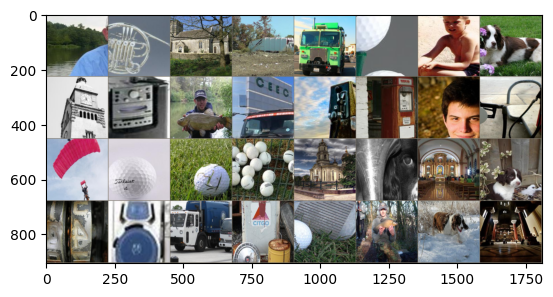

tench, french horn, church, garbage truck, garbage truck, golf ball, english springer, english springer, church, cassette player, tench, garbage truck, gas pump, gas pump, french horn, gas pump, parachute, golf ball, golf ball, golf ball, church, english springer, church, english springer, gas pump, cassette player, garbage truck, gas pump, golf ball, tench, english springer, church


In [5]:
import matplotlib.pyplot as plt
import numpy as np

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# function to show an image
def imshow(img):
  print(img.shape)
  img = img * IMAGENET_STD + IMAGENET_MEAN   # Normalize invertieren
  img = img.clamp(0, 1)                       # numerische Rundungsausreißer abfangen
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

# sample data
# dataiter = iter(trainloader)
dataiter = iter(train_loader)
images, labels = next(dataiter)

#show images
imshow(torchvision.utils.make_grid(images))
print(', '.join(f"{classes[labels[j]]:5s}" for j in range(BATCH_SIZE)))

In [36]:
import torch.nn as nn
import torch.nn.functional as F

class CNNClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 16, 5, 2)
    self.conv2 = nn.Conv2d(16, 32, 3)
    self.conv3 = nn.Conv2d(32, 64, 5, 2)
    self.conv4 = nn.Conv2d(64, 128, 3, 1)

    self.pool = nn.MaxPool2d(2, 2)

    self.classify = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    x = F.relu(self.conv1(x))
    # print(x.shape)
    print(x.mean().item(), x.std().item())
    x = F.relu(self.conv2(x))
    x = self.pool(x)
    print(x.mean().item(), x.std().item())
    # print(x.shape)
    x = F.relu(self.conv3(x))
    # print(x.shape)
    print(x.mean().item(), x.std().item())
    x = self.pool(x)
    # print(x.shape)
    x = F.relu(self.conv4(x))
    # x = self.pool(x)
    # print(x.shape)
    print(x.mean().item(), x.std().item())
    print("==== NEW BATCH ====")
    x = self.classify(x)
    return x

data = torch.rand_like(images)
print(data.shape)
model = CNNClassifier()
output = model(data)
print(output.shape)
print(sum(p.numel() for p in model.parameters()))

torch.Size([32, 3, 224, 224])
0.10862667113542557 0.17235368490219116
0.07056756317615509 0.078069768846035
0.025185318663716316 0.04001183807849884
0.016407299786806107 0.025341860949993134
==== NEW BATCH ====
torch.Size([32, 10])
139882


In [7]:
criterion = nn.CrossEntropyLoss()

In [13]:
import torch.optim as optim
def train(model, train_loader, val_loader, epochs = 10, lr = 0.01):
  optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
  for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
      inputs, labels = data
      inputs = inputs.to(DEVICE)
      labels = labels.to(DEVICE)

      # zero out gradients
      optimizer.zero_grad()

      # fp + bp + step
      outputs = model(inputs).to(DEVICE)
      loss = criterion(outputs, labels).to(DEVICE)
      loss.backward()
      optimizer.step()

      # print statistics
      running_loss += loss.item()
      if i % 10 == 9:    # print every 1000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 10:.3f}')
          running_loss = 0.0


In [21]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [37]:
classifier = CNNClassifier()
# classifier = SimpleCNN()
# DEVICE = "cpu"
classifier.to(DEVICE)
print(sum(p.numel() for p in classifier.parameters()))
train(classifier, train_loader, val_loader, lr=0.001)

139882
0.32817232608795166 0.5085214972496033
0.15321382880210876 0.2349681258201599
0.06255610287189484 0.09748988598585129
0.026953700929880142 0.04226546734571457
==== NEW BATCH ====
0.32593780755996704 0.5138698816299438
0.1507302075624466 0.2340758591890335
0.06161287799477577 0.09678365290164948
0.026645813137292862 0.04162585362792015
==== NEW BATCH ====
0.3270639479160309 0.5145484209060669
0.15458530187606812 0.2362515926361084
0.06274387985467911 0.0985201895236969
0.027091674506664276 0.042296238243579865
==== NEW BATCH ====
0.3135877847671509 0.48359182476997375
0.14702774584293365 0.2243751734495163
0.060807473957538605 0.09398867934942245
0.026037834584712982 0.040837083011865616
==== NEW BATCH ====
0.3211216628551483 0.49610635638237
0.15115155279636383 0.23233665525913239
0.06186867505311966 0.0965607687830925
0.026329513639211655 0.04134978726506233
==== NEW BATCH ====
0.3334542512893677 0.5145631432533264
0.15373046696186066 0.23812229931354523
0.06335389614105225 0.0

KeyboardInterrupt: 